In [16]:
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os, sys
import torch
from matplotlib.lines import Line2D
from collections import defaultdict
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D


# Root project
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))

if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added to sys.path:", project_root)

from envs import *
from basal_ganglia import *
from stn_gpe import *

# filter warnings
import warnings
warnings.filterwarnings("ignore")



plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 9,                    # Base font size
    "axes.labelsize": 9,              # Axis label font size
    "axes.labelweight": "bold",
    "font.weight": "bold",   
    "axes.titlesize":8,              # Axis title (not fig title)
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize":8,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 2.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})

import pickle


Project root added to sys.path: /Users/charithapalika/Desktop/Lab projects/Decision Making/Light_House_DBS/light_house_DBS_decision_making


# PD Vs DBS

In [17]:
data_file = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'all_cases_data.pkl')

# Read pickle file
with open(data_file, 'rb') as f:
    data = pickle.load(f)


In [18]:
DEL_LIM_ARR = data['DEL_LIM_ARR']
VAR = data['VAR']
VAR_ARR = data['VAR_ARR']
ARM_MONITOR = data['ARM_MONITOR']
NUM_ARM_PICKS_MONITOR = data['NUM_ARM_PICKS_MONITOR']

DP_MONITOR = data['DP_MONITOR']
IP_MONITOR = data['IP_MONITOR']
REWARD_MONITOR = data['REWARD_MONITOR']
ARM_TRACKER = data['ARM_TRACKER']
OPTIMAL_CHOICE_MONITOR = data['OPTIMAL_CHOICE_MONITOR']
ACTUAL_CHOICE_MONITOR = data['ACTUAL_CHOICE_MONITOR']
PROB_OPTIMAL_MONITOR = data['PROB_OPTIMAL_MONITOR']
MEAN_PROB_MONITOR = data['MEAN_PROB_MONITOR']

In [19]:

Mean_Probs_PD = [MEAN_PROB_MONITOR[VAR['PD']][del_lim] for del_lim in DEL_LIM_ARR]
Mean_Probs_std_DBS = [MEAN_PROB_MONITOR[VAR['std_DBS']][del_lim] for del_lim in DEL_LIM_ARR]
Mean_Probs_sector_DBS = [MEAN_PROB_MONITOR[VAR['sector_DBS']][del_lim] for del_lim in DEL_LIM_ARR]

In [20]:
# # plotting bar plot for each del lim on x axis and prob on y axis. Different colors for each var
# bar_width = 0.1
# x_values = np.arange(len(DEL_LIM_ARR))
# alpha = 1

# colors = {'normal':"#054b7c",
#           'PD': "#9f0d03ce",
#           'std_DBS': "#ad7322",
#           'sector_DBS': "#038820",}



# plt.figure(figsize=(4,2))
# plt.bar(x_values - bar_width, Mean_Probs_PD, width=bar_width, label="PD", alpha=alpha, color=colors['PD'], capsize=4)
# plt.bar(x_values, Mean_Probs_std_DBS, width=bar_width, label="Standard DBS", alpha=alpha, color=colors['std_DBS'], capsize=4)
# plt.bar(x_values + bar_width, Mean_Probs_sector_DBS, width=bar_width, label="Sector DBS", alpha=alpha, color = colors['sector_DBS'], capsize=4)
# plt.legend(loc = 'lower center', bbox_to_anchor=(0.5,-0.4), ncol = 3)
# plt.xticks(x_values, [f"{v:.2f}" for v in DEL_LIM_ARR], rotation=0)
# plt.xlabel('$\delta_{lim}$')
# plt.ylabel('$P(Best arm)$')
# plt.show()

# Normal

In [21]:
# Reading normal data
data_file_normal = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'normal_data_1.pkl')

# Read pickle file
with open(data_file_normal, 'rb') as f:
    normal_data = pickle.load(f)


In [22]:
EPOCH_NUM = 3
arm_chosen_monitor_normal = normal_data['arm_chosen_monitor']
reward_monitor_normal = normal_data['reward_monitor'] # recieved rew
dp_monitor_normal = normal_data['dp_monitor']
ip_monitor_normal = normal_data['ip_monitor']
arm_tracker_full_normal = normal_data['arm_tracker_full']
prob_normal = normal_data['prob']
mean_prob_normal = normal_data['mean_prob']
trials_normal = arm_chosen_monitor_normal.shape[1]
epochs_normal = arm_chosen_monitor_normal.shape[0]
num_arms = 4
# arm_means_normal = arm_tracker_full_normal[EPOCH_NUM]
# arm_rew_normal = np.zeros((num_arms, len(arm_means_normal)))
# for i in range(len(arm_means_normal)):
#     arms = arm_means_normal[i]
#     rews = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])
#     arm_rew_normal[:,i] = rews

In [23]:
# color_map_normal = {0: 'Red', 1: 'green', 2: 'steelblue', 3: 'orange'}
# MODIFIED_REW_ARRAY = np.zeros((num_arms,trials_normal))
# for i in range(trials_normal):
#     arm = int(arm_chosen_monitor_normal[EPOCH_NUM][i].detach().numpy())
#     MODIFIED_REW_ARRAY[arm,i] = arm_rew_normal[arm,i]

# plt.figure(figsize = (5,2))    
# for i in range(num_arms):
#     plt.plot(arm_rew_normal[i][0:-2], color = color_map_normal[i], label = i, linewidth = 0.9)

#     non_zero_indices = MODIFIED_REW_ARRAY[i] !=0
#     time = np.arange(trials_normal)
#     filtered_time = time[non_zero_indices]
#     filtered_rewards = MODIFIED_REW_ARRAY[i][non_zero_indices]
#     plt.scatter(filtered_time,filtered_rewards, color = color_map_normal[i], marker = 's', s = 5)
# plt.xlabel('Trials')
# plt.ylabel('$P(Best Arm)$')
# # plt.title('Reward of the arm and choices of arm picking')

# PD

In [24]:
# Reading PD data
data_file_PD = os.path.join(project_root, 'results', 'decision_making_tasks', 'data', 'restless_bandits', 'PD_data.pkl')

# Read pickle file
with open(data_file_PD, 'rb') as f:
    PD_data = pickle.load(f)


In [25]:
EPOCH_NUM = 8
arm_chosen_monitor_PD = PD_data['arm_chosen_monitor']
reward_monitor_PD = PD_data['reward_monitor'] # recieved rew
dp_monitor_PD = PD_data['dp_monitor']
ip_monitor_PD = PD_data['ip_monitor']
arm_tracker_full_PD = PD_data['arm_tracker_full']
prob_PD = PD_data['prob']
mean_prob_PD = PD_data['mean_prob']
trials_PD = arm_chosen_monitor_PD.shape[1]
epochs_PD = arm_chosen_monitor_PD.shape[0]
num_arms = 4
# arm_means_PD = arm_tracker_full_PD[EPOCH_NUM]
# arm_rew_PD = np.zeros((num_arms, len(arm_means_PD)))
# for i in range(len(arm_means_PD)):
#     arms = arm_means_PD[i]
#     rews = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])
#     arm_rew_PD[:,i] = rews

In [26]:
# color_map_PD = {0: 'Red', 1: 'green', 2: 'steelblue', 3: 'orange'}

# MODIFIED_REW_ARRAY = np.zeros((num_arms,trials_PD))
# for i in range(trials_PD):
#     arm = int(arm_chosen_monitor_PD[EPOCH_NUM][i].detach().numpy())
#     MODIFIED_REW_ARRAY[arm,i] = arm_rew_PD[arm,i]

# plt.figure(figsize = (5,2))    
# for i in range(num_arms):
#     plt.plot(arm_rew_PD[i][0:-2], color = color_map_PD[i], label = i, linewidth = 0.9)

#     non_zero_indices = MODIFIED_REW_ARRAY[i] !=0
#     time = np.arange(trials_PD)
#     filtered_time = time[non_zero_indices]
#     filtered_rewards = MODIFIED_REW_ARRAY[i][non_zero_indices]
#     plt.scatter(filtered_time,filtered_rewards, color = color_map_PD[i], marker = 's', s = 5)
# plt.xlabel('Trials')
# plt.ylabel('$P(Best Arm)$')
# # plt.title('Reward of the arm and choices of arm picking')

In [27]:
print(f'Mean prob normal: {np.mean(prob_normal)}, Mean prob PD: {np.mean(prob_PD)}')

Mean prob normal: 0.6213333333333334, Mean prob PD: 0.34973333333333334


# Grid plot

In [33]:
# Ensure epoch selections
EPOCH_NORMAL = 21
EPOCH_PD = 8

# Recompute arm rewards (if variables not in scope) — safe to reuse existing arrays if present
arm_means_normal = arm_tracker_full_normal[EPOCH_NORMAL]
arm_rew_normal = np.zeros((4, len(arm_means_normal)))
for i in range(len(arm_means_normal)):
    arms = arm_means_normal[i]
    arm_rew_normal[:, i] = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])

arm_means_PD = arm_tracker_full_PD[EPOCH_PD]
arm_rew_PD = np.zeros((4, len(arm_means_PD)))
for i in range(len(arm_means_PD)):
    arms = arm_means_PD[i]
    arm_rew_PD[:, i] = np.array([arms[0][0], arms[1][0], arms[2][0], arms[3][0]])

# Pick maps for scatter markers (who was chosen)
chosen_normal = [int(x.detach().numpy()) for x in arm_chosen_monitor_normal[EPOCH_NORMAL]]
chosen_PD = [int(x.detach().numpy()) for x in arm_chosen_monitor_PD[EPOCH_PD]]

colors = {'normal':"#054b7c",
          'PD': "#9f0d03ff",
          'std_DBS': "#ad7322",
          'sector_DBS': "#038820",}


color_map_PD = {0: '#FF0000', 1: '#008000', 2: '#4682B4', 3: '#FFA500'}
color_map_normal = {0: '#FF0000', 1: '#008000', 2: '#4682B4', 3: '#FFA500'}

color_map_normal_scatter = {0: "#FF0000BB", 1: "#008000C4", 2: "#4683B4B6", 3: "#FFA600BD"}
color_map_PD_scatter = {0: "#FF0000BB", 1: "#008000C4", 2: "#4683B4B6", 3: "#FFA600BD"}



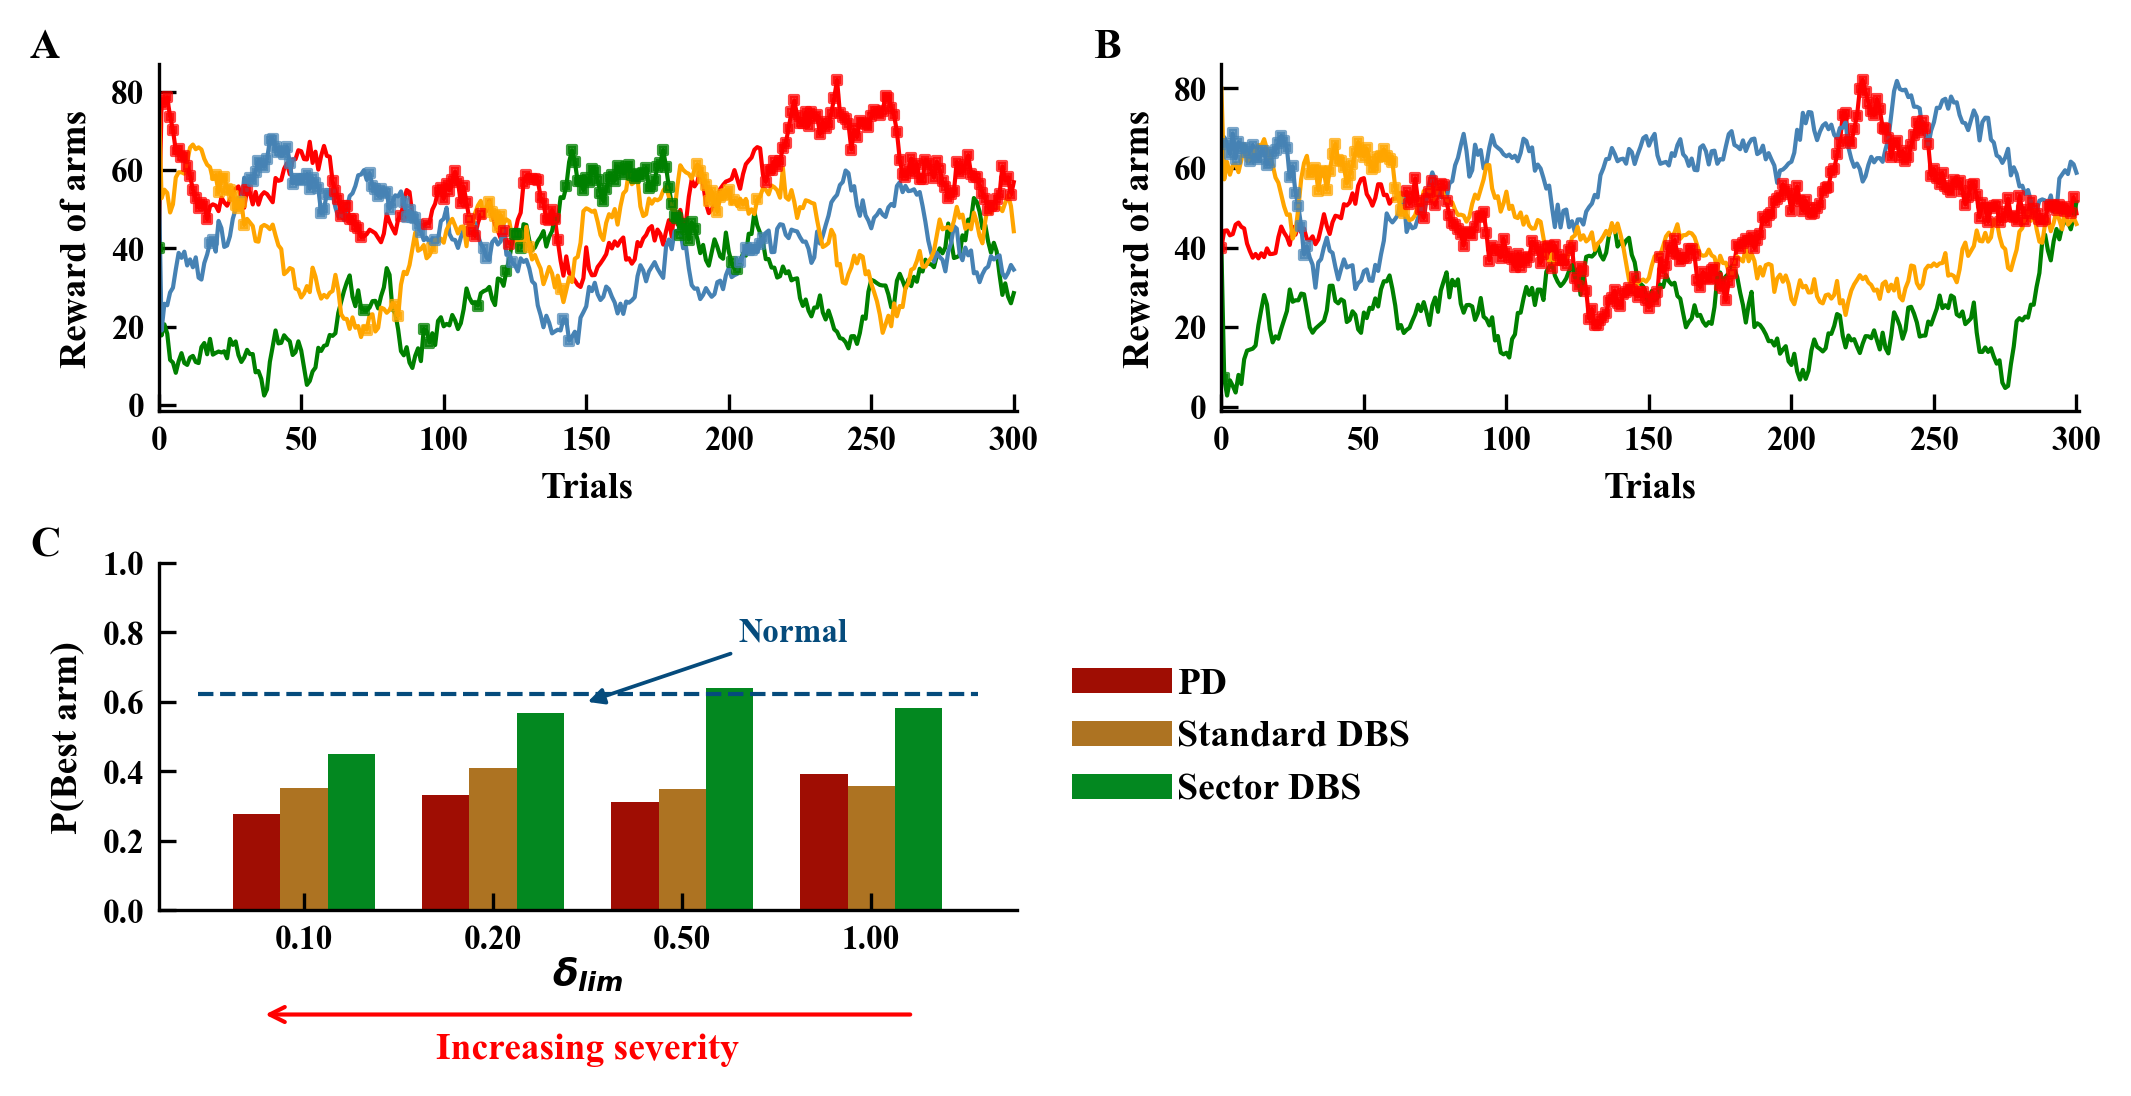

In [36]:

fig = plt.figure(figsize=(7, 3.5), facecolor='white')
gs = fig.add_gridspec(nrows=2, ncols=2, width_ratios=[1,1], height_ratios=[1, 1], hspace=0.01)

ax_normal = fig.add_subplot(gs[0, 0])   # top-left
ax_PD     = fig.add_subplot(gs[0, 1])   # top-right
ax_bar    = fig.add_subplot(gs[1, 0]) # bottom spanning two columns
ax_legend  = fig.add_subplot(gs[1,1])  # narrow right column for legends

# hide legend axis background
ax_legend.axis('off')

# Top-left: Normal lines + picks
trials_normal = arm_rew_normal.shape[1]
time_normal = np.arange(trials_normal)
for i in range(4):
    ax_normal.plot(time_normal, arm_rew_normal[i, :]*100, color=color_map_normal[i], label=f'arm {i}', linewidth=1.0)
for t, pick in enumerate(chosen_normal):
    ax_normal.scatter(t, arm_rew_normal[pick, t]*100, color=color_map_normal_scatter[pick], s=3, marker='s', zorder = 2)
ax_normal.set_xlabel('Trials')
ax_normal.set_ylabel('Reward of arms')
ax_normal.set_xlim(0, trials_normal)

# Top-right: PD lines + picks
trials_PD = arm_rew_PD.shape[1]
time_PD = np.arange(trials_PD)
for i in range(4):
    ax_PD.plot(time_PD, arm_rew_PD[i, :]*100, color=color_map_PD[i], label=f'arm {i}', linewidth=1.0)
for t, pick in enumerate(chosen_PD):
    ax_PD.scatter(t, arm_rew_PD[pick, t]*100, color=color_map_PD_scatter[pick], s=3, marker='s', zorder = 2)
ax_PD.set_xlabel('Trials')
ax_PD.set_ylabel('Reward of arms')
ax_PD.set_xlim(0, trials_PD)

# Bottom (centered) bar plot spanning two columns
bar_width = 0.25
x_values = np.arange(len(DEL_LIM_ARR))
ax_bar.bar(x_values - bar_width, Mean_Probs_PD, width=bar_width, label="PD", color=colors['PD'], edgecolor='none')
ax_bar.bar(x_values,Mean_Probs_std_DBS, width=bar_width, label="Standard DBS", color=colors['std_DBS'], edgecolor='none')
ax_bar.bar(x_values + bar_width, Mean_Probs_sector_DBS, width=bar_width, label="Sector DBS", color=colors['sector_DBS'], edgecolor='none')

ax_bar.set_xticks(x_values)
ax_bar.set_xticklabels([f"{v:.2f}" for v in DEL_LIM_ARR])
ax_bar.set_xlabel('$\\delta_{lim}$', labelpad = 0)
ax_bar.set_ylabel('P(Best arm)')
ax_bar.set_ylim(0, 1)
x_min, x_max = ax_bar.get_xlim()
ax_bar.hlines(np.mean(prob_normal), x_min, x_max, color=colors['normal'], linestyle='--', linewidth=1.0)
x_ann = x_min + 0.5 * (x_max - x_min)               # near left/y-axis
y_ann = 0.6
y_text = 0.8 

ax_bar.annotate(
    'Normal',
    xy=(x_ann, y_ann),
    xytext=(x_ann + 0.8, y_text),
    arrowprops=dict(arrowstyle='-|>', color=colors['normal'], lw=0.9, shrinkA=0, shrinkB=0),
    fontsize=8, fontweight='bold', color=colors['normal'], va='center'
)


x_start = x_values[-1] + bar_width
x_end = x_values[0] - bar_width
y_pos = -0.3
ax_bar.annotate(
    '',  # No text at the arrow tip
    xy=(x_end, y_pos),           # Arrow tip coordinates (end point)
    xytext=(x_start, y_pos),     # Text and arrow tail coordinates (start point)
    xycoords=('data', 'axes fraction'), # Use data coords for x, axes fraction for y
    textcoords=('data', 'axes fraction'),
    arrowprops=dict(
        arrowstyle="->",         # Style of the arrow head
        color='red',           # Color of the arrow
        linewidth=1
    )
)

# 4. Add the text at the center of the arrow.
ax_bar.annotate(
    'Increasing severity',
    xy=((x_start + x_end) / 2, y_pos-0.1), # Center point of the arrow
    xycoords=('data', 'axes fraction'),
    ha='center',                 # Horizontal alignment
    va='center',                 # Vertical alignment (center on the arrow line)
    fontsize=9,
    color='red'
)


# Put the legend in the right-hand column (ax_legend) so it's vertically centered next to the bar plot
handles = [Line2D([0], [0], color=colors['PD'], lw=6),
           Line2D([0], [0], color=colors['std_DBS'], lw=6),
           Line2D([0], [0], color=colors['sector_DBS'], lw=6)]
labels = ['PD', 'Standard DBS', 'Sector DBS']
ax_legend.legend(handles, labels, loc='center left', frameon=False, fontsize=9, bbox_to_anchor=(-0.2, 0.5))



# add subplot letters
labels = ['A', 'B', 'C']
for n, ax in enumerate([ax_normal, ax_PD, ax_bar]):
    ax.text(-0.15, 1.1, labels[n], transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

plt.show()
